# SentinelAI — 03 Supervised Models (Validation Selection)

ندرب:
1. Random Forest
2. Logistic Regression
3. Gradient Boosting (XGBoost)

**المقارنة هنا على Validation فقط.** لا يتم تحميل `X_test` في هذا الملف.

In [1]:
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

cwd = Path.cwd()
BASE_DIR = cwd.parent if cwd.name == "notebooks" else cwd
P = BASE_DIR / "data" / "processed"
M = BASE_DIR / "models"
M.mkdir(exist_ok=True)

X_train = np.load(P / "X_train.npy")
X_val = np.load(P / "X_val.npy")
y_train = np.load(P / "y_train.npy")
y_val = np.load(P / "y_val.npy")

label_mapping = {int(k): v for k, v in json.loads((P/"label_mapping.json").read_text(encoding="utf-8")).items()}
class_weights = {int(k): v for k, v in json.loads((P/"class_weights.json").read_text(encoding="utf-8")).items()}

classes_sorted = sorted(label_mapping)
class_names = [label_mapping[c] for c in classes_sorted]

print("Train:", X_train.shape, "Validation:", X_val.shape)

Train: (908327, 77) Validation: (113541, 77)


In [2]:
def metrics_row(name, y_true, y_pred, seconds):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "Model": name,
        "Evaluation_Split": "validation",
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": p,
        "Recall_macro": r,
        "F1_macro": f1,
        "Train_seconds": seconds,
    }

def show_report(name, y_true, y_pred):
    print("\n", "="*20, name, "="*20)
    print(classification_report(
        y_true, y_pred,
        labels=classes_sorted,
        target_names=class_names,
        zero_division=0,
    ))
    cm = confusion_matrix(y_true, y_pred, labels=classes_sorted)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues", fmt="d", annot=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} — Validation")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

rows = []


 ==================== Random Forest ====================
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     88006
    Attack_2       1.00      1.00      1.00      3513
    Attack_3       1.00      1.00      1.00      3381
    Attack_4       1.00      1.00      1.00     12428
    Attack_5       1.00      1.00      1.00      5205
    Attack_6       1.00      1.00      1.00       760
    Attack_7       1.00      1.00      1.00       203
    Attack_8       1.00      1.00      1.00        30
    Attack_9       0.21      0.78      0.33         9
   Attack_10       0.83      1.00      0.91         5
   Attack_11       0.50      1.00      0.67         1

    accuracy                           1.00    113541
   macro avg       0.87      0.98      0.90    113541
weighted avg       1.00      1.00      1.00    113541



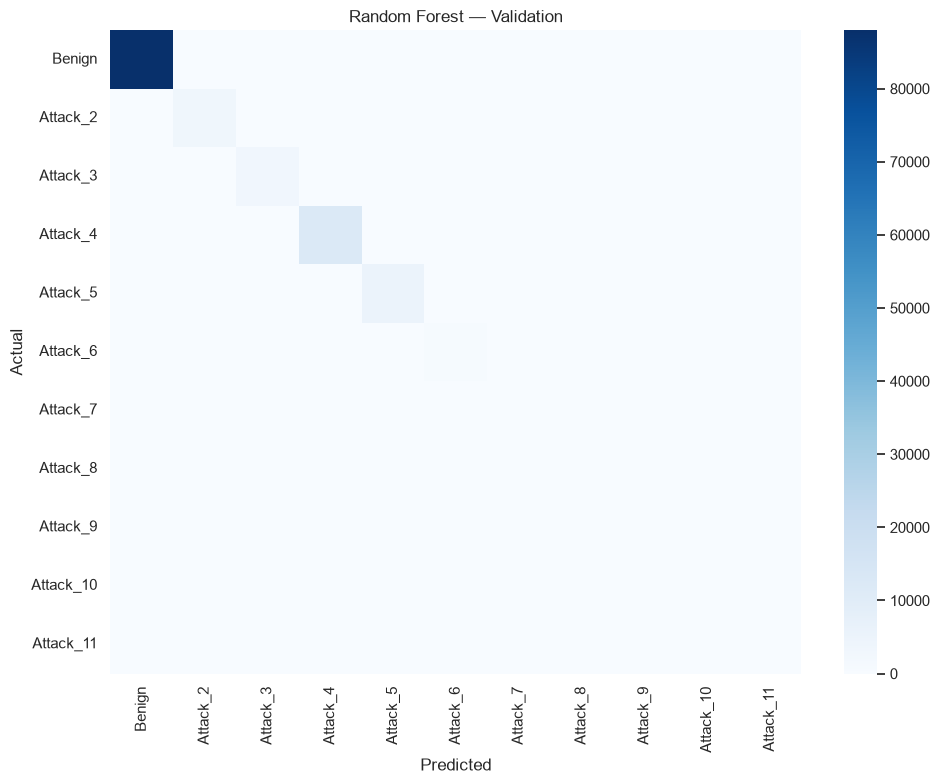

['F:\\SentinelAI\\models\\random_forest.joblib']

In [3]:
start = time.time()
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight=class_weights,
)
rf.fit(X_train, y_train)
rf_seconds = time.time() - start
rf_pred = rf.predict(X_val)
rows.append(metrics_row("Random Forest", y_val, rf_pred, rf_seconds))
show_report("Random Forest", y_val, rf_pred)
joblib.dump(rf, M / "random_forest.joblib")

F:\SentinelAI\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 ==================== Logistic Regression ====================
              precision    recall  f1-score   support

      Benign       1.00      0.92      0.96     88006
    Attack_2       1.00      1.00      1.00      3513
    Attack_3       1.00      1.00      1.00      3381
    Attack_4       0.97      1.00      0.98     12428
    Attack_5       0.88      1.00      0.93      5205
    Attack_6       0.98      1.00      0.99       760
    Attack_7       0.67      1.00      0.80       203
    Attack_8       1.00      1.00      1.00        30
    Attack_9       0.00      0.44      0.01         9
   Attack_10       0.00      1.00      0.00         5
   Attack_11       0.01      1.00      0.02         1

    accuracy                           0.93    113541
   macro avg       0.68      0.94      0.70    113541
weighted avg       0.99      0.93      0.96    113541



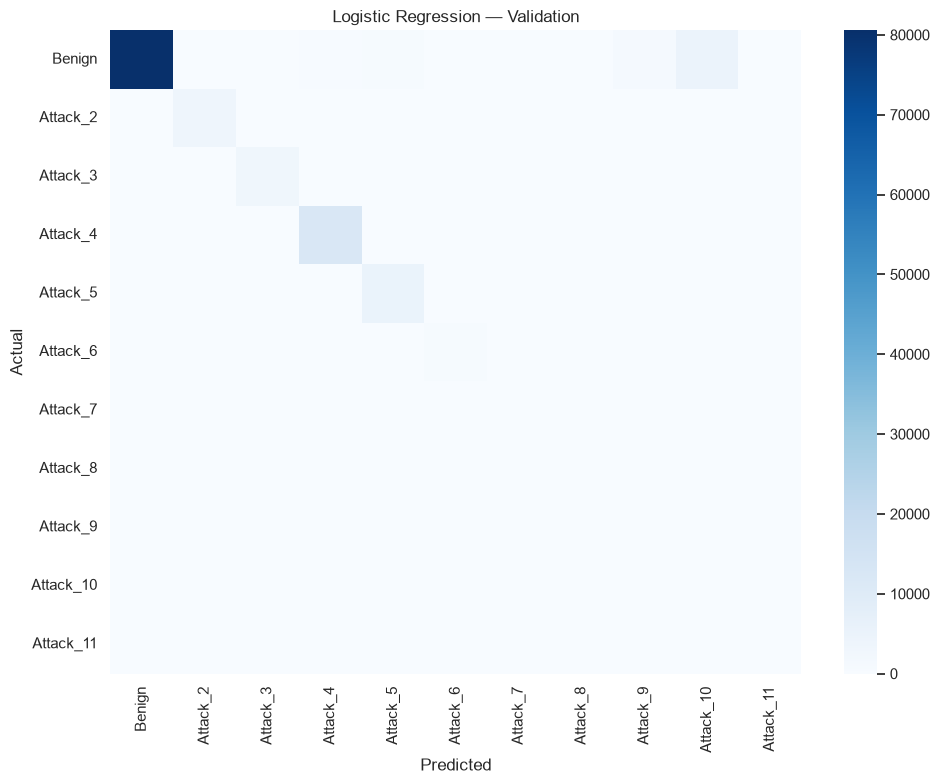

['F:\\SentinelAI\\models\\logistic_regression.joblib']

In [4]:
start = time.time()
lr = LogisticRegression(
    max_iter=500,
    class_weight=class_weights,
    solver="lbfgs",
)
lr.fit(X_train, y_train)
lr_seconds = time.time() - start
lr_pred = lr.predict(X_val)
rows.append(metrics_row("Logistic Regression", y_val, lr_pred, lr_seconds))
show_report("Logistic Regression", y_val, lr_pred)
joblib.dump(lr, M / "logistic_regression.joblib")


 ==================== Gradient Boosting (XGBoost) ====================
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     88006
    Attack_2       1.00      1.00      1.00      3513
    Attack_3       1.00      1.00      1.00      3381
    Attack_4       1.00      1.00      1.00     12428
    Attack_5       1.00      1.00      1.00      5205
    Attack_6       1.00      1.00      1.00       760
    Attack_7       0.99      1.00      1.00       203
    Attack_8       1.00      1.00      1.00        30
    Attack_9       0.26      0.89      0.40         9
   Attack_10       0.83      1.00      0.91         5
   Attack_11       1.00      1.00      1.00         1

    accuracy                           1.00    113541
   macro avg       0.92      0.99      0.94    113541
weighted avg       1.00      1.00      1.00    113541



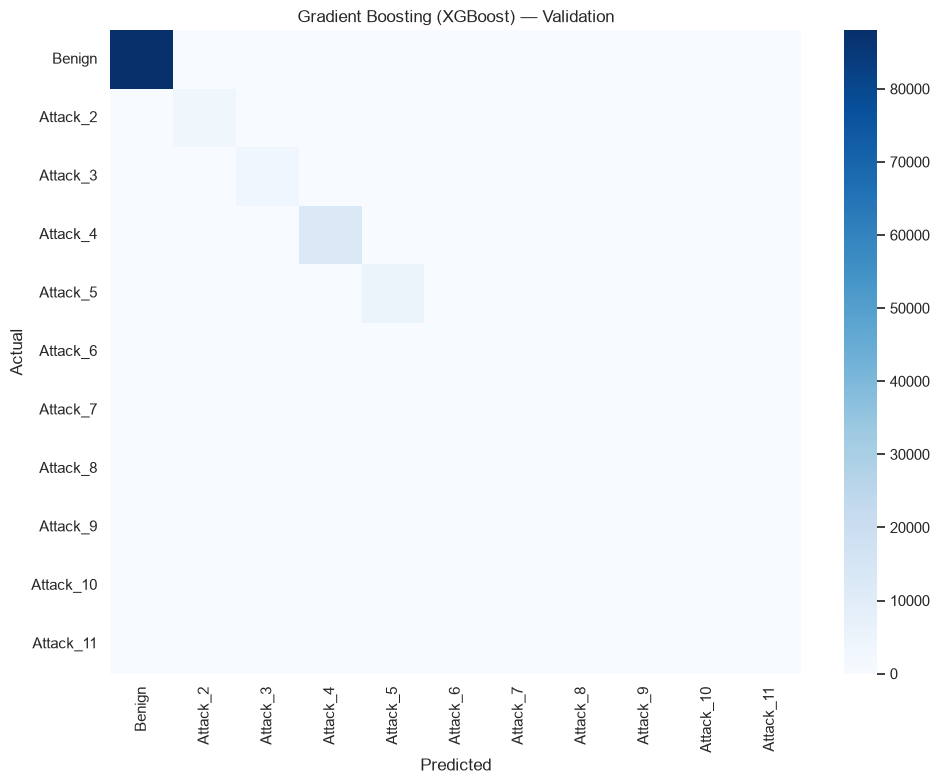

['F:\\SentinelAI\\models\\xgboost_label_encoder.joblib']

In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_train_enc = label_encoder.transform(y_train)

sample_weight_train = np.array([class_weights[int(v)] for v in y_train], dtype=float)

start = time.time()
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(X_train, y_train_enc, sample_weight=sample_weight_train)
xgb_seconds = time.time() - start

xgb_pred = label_encoder.inverse_transform(xgb.predict(X_val).astype(int))
rows.append(metrics_row("Gradient Boosting (XGBoost)", y_val, xgb_pred, xgb_seconds))
show_report("Gradient Boosting (XGBoost)", y_val, xgb_pred)

joblib.dump(xgb, M / "gradient_boosting_xgboost.joblib")
joblib.dump(label_encoder, M / "xgboost_label_encoder.joblib")

In [6]:
comparison = pd.DataFrame(rows).sort_values("F1_macro", ascending=False).reset_index(drop=True)
comparison.to_csv(M / "supervised_comparison.csv", index=False)

print("Selection leaderboard — VALIDATION ONLY")
display(comparison)
print("\nBest supervised baseline:", comparison.iloc[0]["Model"])

Selection leaderboard — VALIDATION ONLY


,Model,Evaluation_Split,Accuracy,Precision_macro,Recall_macro,F1_macro,Train_seconds
0,Gradient Boosting (XGBoost),validation,0.999727,0.916442,0.989800,0.936659,171.284909
1,Random Forest,validation,0.999498,0.866985,0.979657,0.899943,56.159275
2,Logistic Regression,validation,0.934147,0.682286,0.941311,0.699078,231.113081



Best supervised baseline: Gradient Boosting (XGBoost)


`X_test` لم يتم تحميله، لذلك هذه المقارنة لا تستهلك الاختبار النهائي.